In [1]:
!pip -q install torch torchvision matplotlib tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm

In [2]:
# -------------------------
# Synthetic visual counting dataset
# -------------------------
class ObjectCountingDataset(Dataset):
    def __init__(self, n_samples=10000, image_size=64, max_objects=5):
        self.n_samples = n_samples
        self.image_size = image_size
        self.max_objects = max_objects

    def __len__(self):
        return self.n_samples

    def __getitem__(self, idx):
        img = np.zeros((self.image_size, self.image_size), dtype=np.float32)

        count = np.random.randint(1, self.max_objects + 1)

        for _ in range(count):
            radius = np.random.randint(3, 7)
            x = np.random.randint(radius, self.image_size - radius)
            y = np.random.randint(radius, self.image_size - radius)

            yy, xx = np.ogrid[:self.image_size, :self.image_size]
            mask = (xx - x) ** 2 + (yy - y) ** 2 <= radius ** 2
            img[mask] = 1.0

        img = torch.tensor(img).unsqueeze(0)
        label = torch.tensor(count - 1, dtype=torch.long)  # classes 0–4

        return img, label

In [3]:
# -------------------------
# Data loaders
# -------------------------
train_dataset = ObjectCountingDataset(n_samples=20000)
test_dataset = ObjectCountingDataset(n_samples=3000)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128)

In [4]:
# -------------------------
# CNN model
# -------------------------
class CountingCNN(nn.Module):
    def __init__(self, num_classes=5):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [ ]:
# -------------------------
# Train
# -------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
model = CountingCNN().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

epochs = 8

for epoch in range(epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        preds = logits.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    train_acc = correct / total

    print(f"Epoch {epoch+1}: loss={total_loss/len(train_loader):.4f}, acc={train_acc:.3f}")

  0%|          | 0/157 [00:00<?, ?it/s]

In [6]:
# -------------------------
# Evaluate
# -------------------------
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = logits.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test accuracy:", correct / total)

Test accuracy: 0.8826666666666667


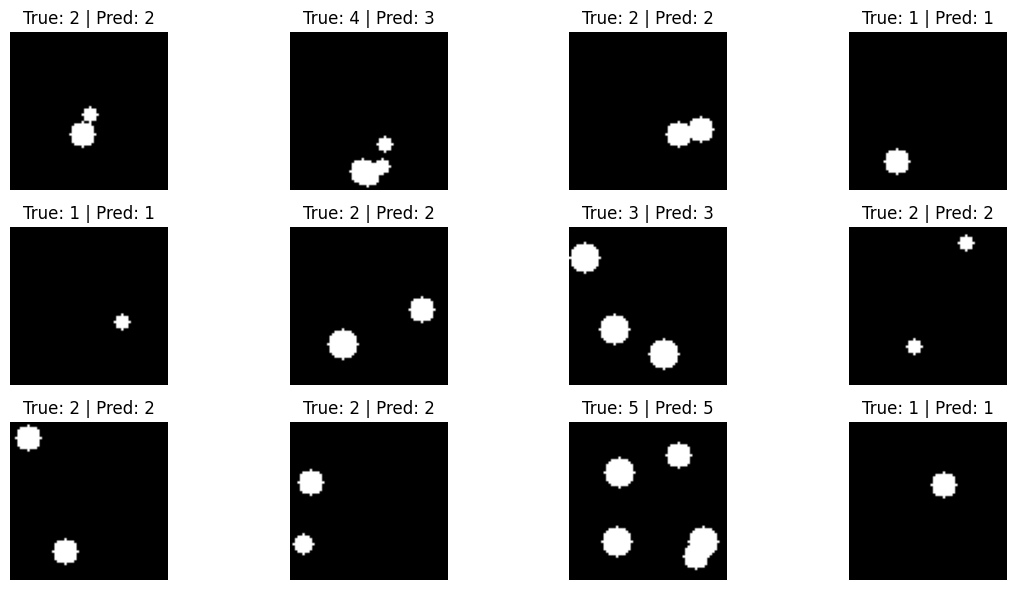

In [7]:
# -------------------------
# Visualize predictions
# -------------------------
model.eval()

images, labels = next(iter(test_loader))
images = images.to(device)

with torch.no_grad():
    logits = model(images)
    preds = logits.argmax(dim=1).cpu().numpy() + 1

labels = labels.numpy() + 1
images = images.cpu()

plt.figure(figsize=(12, 6))

for i in range(12):
    plt.subplot(3, 4, i + 1)
    plt.imshow(images[i, 0], cmap="gray")
    plt.title(f"True: {labels[i]} | Pred: {preds[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()